# ML Model Selection

This notebook is used for selecting a best ML model to apply into BigQuery ML. Since BigQuery ML cost is high for many iterations of model training, we use local for training ML because it will not incur any cost.

We don't pick model directly from local since our goal is to use BigQuery ML. We just pick model parameters and apply it into BigQuery ML.

For reference, we will compare only 3 models:

| Machine Learning | Sklearn | BQML |
| --- | --- | --- |
| Linear Regression | `Ridge` | `LINEAR_REG` |
| Random Forest | `XGBRFRegressor` | `RANDOM_FOREST_REGRESSOR` |
| Gradient Boosting | `XGBRegressor` | `BOOSTED_TREE_REGRESSOR` |

In [1]:
# setup source path
import sys
import os

# add source directory to python path for custom modules
src_path = os.path.join(os.getcwd(), "..", "scripts")

if src_path not in sys.path:
    sys.path.append(src_path)
    print(f"Added {os.path.relpath(src_path)} to sys.path")  
else:
    print(f"{os.path.relpath(src_path)} already in sys.path")  

Added ../scripts to sys.path


In [18]:
# import library
from load_benchmark_to_bq import (
    PROJECT, BUCKET, DATASET, TABLE
)

from pathlib import Path
import json
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="dark")

from scipy.stats import skew
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNet
from xgboost import XGBRegressor, XGBRFRegressor

RANDOM_STATE=42

# Exploratory Data Analysis

In [3]:
# load data
path = Path.cwd() / ".." / "results" / "benchmark_results.csv"
df = pd.read_csv(path)

# show data
df.head()

,tier_months,variant,query_id,has_partition,has_cluster,table_size_bytes,partition_filter_ratio,cluster_filter_ratio,bytes_processed
0,2,none,1,False,False,1201852092,0.017544,0.047572,128179760
1,2,none,2,False,False,1201852092,0.017544,0.015565,128179760
2,2,none,3,False,False,1201852092,0.017544,0.001544,128179760
3,2,none,4,False,False,1201852092,0.017544,0.000344,128179760
4,2,none,5,False,False,1201852092,0.017544,0.000094,128179760


In [4]:
# divide columns into numerical and categorical
numerical_cols = ["table_size_bytes", "partition_filter_ratio", "cluster_filter_ratio", "bytes_processed"]
categorical_cols = ["has_partition", "has_cluster"]

# show descriptive statistics
print("Descriptive statistics for numerical columns:")
display(df[numerical_cols].describe())
print("\nDescriptive statistics for categorical columns:")
display(df[categorical_cols].describe())

# show null data
print(f"\nNull values in the dataset:\n{df.isnull().sum().sum()}")

# show duplicated values
print(f"\nDuplicated values in the dataset:\n{df.duplicated().sum()}")

Descriptive statistics for numerical columns:


,table_size_bytes,partition_filter_ratio,cluster_filter_ratio,bytes_processed
count,4.004000e+03,4004.000000,4004.000000,4.004000e+03
mean,5.142550e+09,0.288684,0.008848,2.145891e+08
std,1.806585e+09,0.261833,0.015482,2.507522e+08
min,1.201852e+09,0.002770,0.000000,1.884480e+05
25%,3.512204e+09,0.060345,0.000002,1.047894e+07
50%,5.998169e+09,0.200000,0.000340,8.972854e+07
75%,7.234807e+09,0.500000,0.015432,3.770166e+08
max,7.234807e+09,1.000000,0.047572,7.761573e+08



Descriptive statistics for categorical columns:


,has_partition,has_cluster
count,4004,4004
unique,2,2
top,False,False
freq,2002,2002



Null values in the dataset:
0

Duplicated values in the dataset:
0


Based on the descriptive statistics, `bytes_processed` has a large difference between its mean and median, suggesting that the distribution is right-skewed. We will analyze its distribution further in the next section.

In addition, `has_partition` and `has_cluster` are boolean features. Since BQML automatically encodes boolean values as `0` and `1`, we apply the same encoding in the scikit-learn pipeline to ensure both models use identical feature representations for a fair comparison. 

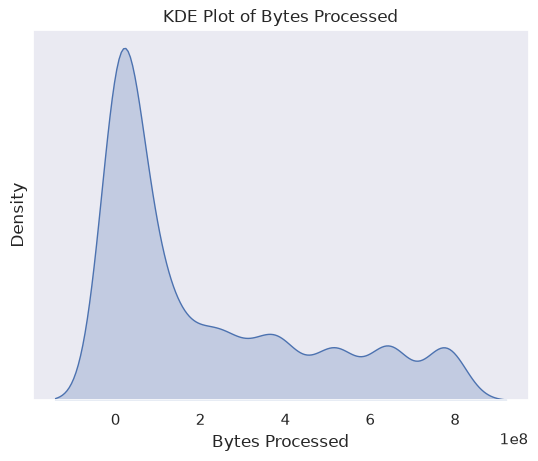

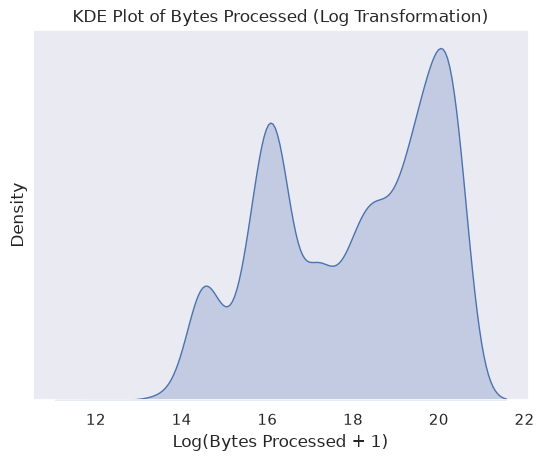

Skewness of bytes_processed: 1.01
Skewness of log_bytes_processed: -0.32


In [5]:
# create the KDE plot for bytes_processed
sns.kdeplot(data=df, x="bytes_processed", fill=True)
plt.title("KDE Plot of Bytes Processed")
plt.xlabel("Bytes Processed")
plt.yticks([])
plt.show()

# create the KDE plot for bytes_processed after log transformation
_test = df.copy()
_test["log_bytes_processed"] = np.log1p(_test["bytes_processed"])
sns.kdeplot(data=_test, x="log_bytes_processed", fill=True)
plt.title("KDE Plot of Bytes Processed (Log Transformation)")
plt.xlabel("Log(Bytes Processed + 1)")
plt.yticks([])
plt.show()

# check skewness
print(f"Skewness of bytes_processed: {skew(df['bytes_processed']):.2f}")
print(f"Skewness of log_bytes_processed: {skew(_test['log_bytes_processed']):.2f}")

Since the log transformation reduces the skewness of `bytes_processed`, we apply it before training the Linear Regression model. We use `log1p` instead of the standard logarithm because it safely handles zero values by computing `log(x + 1)`.

# Preparation

## Data

In [6]:
# copy data
df_ml = df.copy()

# check info
df_ml[['has_partition','has_cluster']].info() # it still bool so we need to convert into int

# change into int
df_ml['has_partition'] = df_ml['has_partition'].astype(int)
df_ml['has_cluster'] = df_ml['has_cluster'].astype(int)

# check info again
print()
df_ml[['has_partition','has_cluster']].info() # now it is int

<class 'pandas.DataFrame'>
RangeIndex: 4004 entries, 0 to 4003
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   has_partition  4004 non-null   bool 
 1   has_cluster    4004 non-null   bool 
dtypes: bool(2)
memory usage: 7.9 KB

<class 'pandas.DataFrame'>
RangeIndex: 4004 entries, 0 to 4003
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   has_partition  4004 non-null   int64
 1   has_cluster    4004 non-null   int64
dtypes: int64(2)
memory usage: 62.7 KB


## Function

In [7]:
def evaluate(model, X_tr, X_te, y_tr, y_te):
    """
    Evaluate model prediction. Variable y must be byte. Model prediction must be log.
    """
    p_tr = np.expm1(model.predict(X_tr))
    p_te = np.expm1(model.predict(X_te))

    r2_train = r2_score(y_tr, p_tr)
    r2_test = r2_score(y_te, p_te)
    r2_gap_pct = abs(r2_test - r2_train) / abs(r2_train) * 100

    mae_train = mean_absolute_error(y_tr, p_tr)
    mae_test = mean_absolute_error(y_te, p_te)
    mae_gap_pct = abs(mae_test - mae_train) / mae_train * 100

    if r2_train < 0.90:
        fit = "underfit"
    elif r2_gap_pct > 10:
        fit = "overfit"
    else:
        fit = "good fit"

    return {
        "r2_train": r2_train,
        "r2_test": r2_test,
        "r2_gap_pct": r2_gap_pct,
        "mae_train_mb": mae_train / 1e6,
        "mae_test_mb": mae_test / 1e6,
        "mae_gap_pct": mae_gap_pct,
        "fit": fit,
    }

def mae_scorer(model, X, y):
    """
    Scorer for CV. Variable y must be byte. Model prediction must be log.
    """
    p = np.expm1(model.predict(X))
    return -mean_absolute_error(y, p)

def show_result(result, model_name, round=5, sort="mae_test_mb"):
    """
    Show result from Evaluate function.
    """
    df = pd.DataFrame(
        {k: v for k, v in result.items() if model_name in k}
    ).T

    for col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col])
        except (ValueError, TypeError):
            pass

    return df.round(round).sort_values(sort)

## Split

In [8]:
# define feature and cluster
FEATURES = ["has_partition", "has_cluster", "table_size_bytes", "partition_filter_ratio", "cluster_filter_ratio"]
TARGET = "bytes_processed"

X = df_ml[FEATURES].copy()
y = df_ml[TARGET].copy()

# train test split
idx_train, idx_test = train_test_split(df_ml.index, test_size=0.2, random_state=RANDOM_STATE)
X_train, X_test = X.loc[idx_train], X.loc[idx_test]
y_train, y_test = y.loc[idx_train], y.loc[idx_test]
ylog_train, ylog_test = np.log1p(y_train), np.log1p(y_test)

print(f"Split into train: {X_train.shape} and test: {X_test.shape}")

Split into train: (3203, 5) and test: (801, 5)


# Building

We build and compare three machine learning models to determine which performs best. Each model is evaluated on both the train and test data using two metrics: `R²` and `Mean Absolute Error (MAE)`, where MAE is reported in megabytes (MB).

R² measures the proportion of variance in the target variable explained by the model. It is also used to assess whether a model is underfitting, overfitting, or generalizing well. MAE measures the average absolute difference between the predicted and actual bytes_processed values, providing an interpretable error in MB.

We classify model performance using the following criteria:

1. Underfit: Training R² is below 0.90
2. Overfit: The absolute difference between the training and testing R² exceeds 10%
3. Good fit: The model is neither underfit nor overfit

Among the models classified as good fit, the best model is the one with the lowest MAE on test data, as it achieves the smallest prediction error on unseen data.

In [9]:
# save evaluate result in dictionary
result = {}

## Linear Regression

In [10]:
# make and evaluate linear regression
ols = Pipeline([
    ("scale", StandardScaler()), ("model", LinearRegression()) # we use standard scaler for linear regression for better result
]).fit(X_train, ylog_train)
result["Linear Regression (OLS)"] = evaluate(ols, X_train, X_test, y_train, y_test)

# show result
show_result(result, "Linear Regression")

,r2_train,r2_test,r2_gap_pct,mae_train_mb,mae_test_mb,mae_gap_pct,fit
Linear Regression (OLS),0.19182,0.23469,22.34888,146.05255,133.66809,8.47945,underfit


Based on the evaluation metrics, the `Linear Regression` model is classified as `underfit`, with a training R² of only `0.192`. This indicates that the model explains only about `19.2%` of the variance in `bytes_processed`, suggesting that it `fails` to capture the underlying relationship between the features and the target. 

One possible reason is that Linear Regression assumes a linear and additive relationship between the features and the target. In contrast, the amount of data processed by BigQuery is influenced by more complex interactions.

Since the training performance is already poor, applying regularization techniques, such as Ridge or Lasso, is unlikely to improve the model because regularization generally reduces model complexity rather than increasing it.

## Random Forest

In [11]:
# make and evaluate random forest
rf = XGBRFRegressor(random_state=RANDOM_STATE).fit(X_train, ylog_train)
result["Random Forest"] = evaluate(rf, X_train, X_test, y_train, y_test)

# make and evaluate random forest - tuned
param_dist_rf = {
    "max_depth": [10, 12, 15],
    "n_estimators": [50, 100, 150],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bynode": [0.7, 0.9, 1.0],
    "reg_alpha": [0, 0.5, 1],
    "reg_lambda": [0, 0.5, 1],
}
rf_tuned = RandomizedSearchCV(
    XGBRFRegressor(random_state=RANDOM_STATE),
    param_distributions=param_dist_rf,
    n_iter=100,
    cv=4,
    scoring=mae_scorer,
    random_state=RANDOM_STATE,
    n_jobs=-1
).fit(X_train, ylog_train)
result["Random Forest - Tuned"] = evaluate(rf_tuned, X_train, X_test, y_train, y_test)

# show result
show_result(result, "Random Forest")

,r2_train,r2_test,r2_gap_pct,mae_train_mb,mae_test_mb,mae_gap_pct,fit
Random Forest,0.98382,0.98322,0.06132,14.80620,14.48698,2.15594,good fit
Random Forest - Tuned,0.93994,0.94466,0.50279,31.13031,28.53471,8.33784,good fit


Based on the evaluation metrics, the `Random Forest` model is classified as `good fit`, with a testing R² of above `0.93`. This indicates that the model explains more than `93%` of the variance in `bytes_processed`, suggesting that it `success` to capture the underlying relationship between the features and the target.

Original Random Forest model have better result compare to Tuned Random Forest model.

## Gradient Boosting

In [12]:
# make and evaluate gradient boosting
xgb = XGBRegressor(random_state=RANDOM_STATE).fit(X_train, ylog_train)
result["Gradient Boosting"] = evaluate(xgb, X_train, X_test, y_train, y_test)

# make and evaluate gradient boosting - tuned
param_dist_xgb = {
    "max_depth": [10, 12, 15],
    "learning_rate": [0.1, 0.2, 0.3],
    "n_estimators": [50, 100, 150],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 5, 10],
}
xgb_tuned = RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE),
    param_distributions=param_dist_xgb,
    n_iter=100,
    cv=4,
    scoring=mae_scorer,
    random_state=RANDOM_STATE,
    n_jobs=-1
).fit(X_train, ylog_train)
result["Gradient Boosting - Tuned"] = evaluate(xgb_tuned, X_train, X_test, y_train, y_test)

# show result
show_result(result, "Gradient Boosting")

,r2_train,r2_test,r2_gap_pct,mae_train_mb,mae_test_mb,mae_gap_pct,fit
Gradient Boosting,0.99988,0.99977,0.01105,1.46074,1.96837,34.75117,good fit
Gradient Boosting - Tuned,0.97523,0.93544,4.08014,17.76342,27.37420,54.10433,good fit


Based on the evaluation metrics, the `Gradient Boosting` model is classified as `good fit`, with a testing R² of above `0.97`. This indicates that the model explains more than `97%` of the variance in `bytes_processed`, suggesting that it `success` to capture the underlying relationship between the features and the target.

Original Gradient Boosting model have better result compare to Tuned Gradient Boosting model.

# Summary

## Show Result

In [13]:
show_result(result,"")

,r2_train,r2_test,r2_gap_pct,mae_train_mb,mae_test_mb,mae_gap_pct,fit
Gradient Boosting,0.99988,0.99977,0.01105,1.46074,1.96837,34.75117,good fit
Random Forest,0.98382,0.98322,0.06132,14.80620,14.48698,2.15594,good fit
Gradient Boosting - Tuned,0.97523,0.93544,4.08014,17.76342,27.37420,54.10433,good fit
Random Forest - Tuned,0.93994,0.94466,0.50279,31.13031,28.53471,8.33784,good fit
Linear Regression (OLS),0.19182,0.23469,22.34888,146.05255,133.66809,8.47945,underfit


Among all evaluated models, `Gradient Boosting` achieved the best overall performance. It has the `highest test R²` (0.99977), indicating that it explains nearly all the variance in bytes_processed, while maintaining a very small train–test R² gap. It also has the `lowest test MAE` (1.97 MB), meaning its predictions differ from the actual values by less than 2 MB on average.

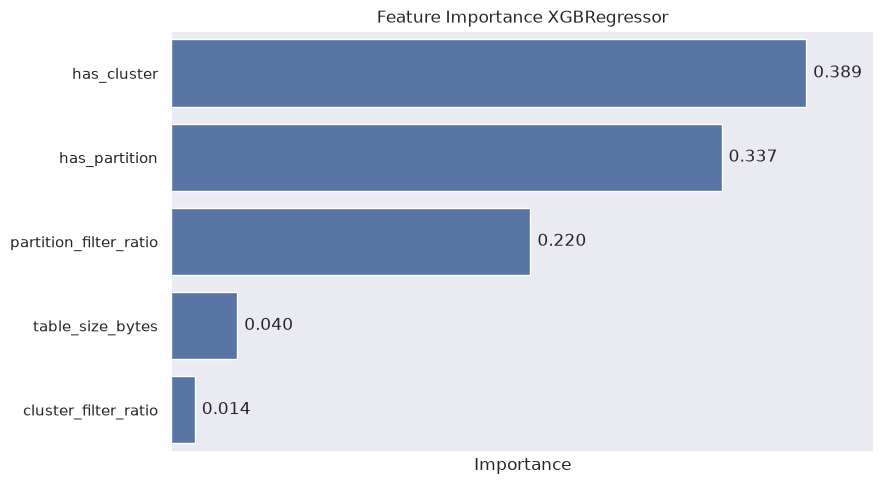

In [14]:
# pick winner model
winner_model = xgb

# Create DataFrame and sort
df_imp = (
    pd.DataFrame({
        "Feature": FEATURES,
        "Importance": winner_model.feature_importances_,
    })
    .sort_values("Importance", ascending=False)
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=df_imp,
    x="Importance",
    y="Feature",
    orient="h"
)

# Annotate values
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=5)

ax.set_xlabel("Importance")
ax.set_xticks([])
ax.set_xlim(0,0.43)
ax.set_ylabel("")
ax.set_title(f"Feature Importance {winner_model.__class__.__name__}")

plt.tight_layout()
plt.show()

The feature importance results show that `has_cluster` (0.389) and `has_partition` (0.337) are the two most influential features for predicting bytes_processed. Together, they account for `more than 72%` of the total importance, indicating that whether a table is clustered or partitioned has the greatest impact on the amount of data scanned by a query.

This suggests that BigQuery's query processing is influenced more by the presence of partitioning and clustering than by the table size itself, likely because these features help reduce the amount of data that needs to be scanned.

## Save Result

In [25]:
# save parameter to copy into bqml
cfg = json.loads(winner_model.get_booster().save_config())
tp = cfg["learner"]["gradient_booster"]["tree_train_param"]
winning_param = {
    "MODEL_TYPE": "BOOSTED_TREE_REGRESSOR",
    "BOOSTER_TYPE": 'GBTREE',
    "TREE_METHOD": "AUTO",
    "MAX_TREE_DEPTH": int(tp["max_depth"]),
    "LEARN_RATE": float(tp['learning_rate']),
    "MAX_TREE_DEPTH": int(tp['max_depth']),
    "MIN_TREE_CHILD_WEIGHT": int(tp['min_child_weight']),
    "SUBSAMPLE": float(tp['subsample']),
    "COLSAMPLE_BYTREE": float(tp['colsample_bytree']),
    "COLSAMPLE_BYLEVEL": float(tp['colsample_bylevel']),
    "COLSAMPLE_BYNODE": float(tp['colsample_bynode']),
    "L1_REG": float(tp['reg_alpha']),
    "L2_REG": float(tp['reg_lambda']),
    "MIN_SPLIT_LOSS": float(tp['gamma']),
    "MAX_ITERATIONS":  int(cfg['learner']['gradient_booster']['gbtree_model_param']['num_trees']),
    "NUM_PARALLEL_TREE": int(cfg['learner']['gradient_booster']['gbtree_model_param']['num_parallel_tree']),
    "DATA_SPLIT_METHOD": 'RANDOM',
    "DATA_SPLIT_EVAL_FRACTION": 0.2,
    "EARLY_STOP": 'FALSE',
    "INPUT_LABEL_COLS": "['bytes_processed']",
    "ENABLE_GLOBAL_EXPLAIN": 'TRUE'
}

# save into .json
json_path = Path.cwd() / ".." / "results" / "best_model_param.json"
with open(json_path, "w") as f:
    json.dump(
        {
            "winner_model": winner_model.__class__.__name__,
            "metrics": show_result(result,"")[0:1].T.to_dict().get('Gradient Boosting'),
            "hyperparameters": winning_param,
            "features": FEATURES,
            "target": TARGET,
            "notes": "No log1p transformation is required for the target variable (unlike Linear Regression, this model can use raw bytes target)"
        }, f, indent=2
    )

# show .json content
with open(json_path, "r") as f:
    data = json.load(f)

print(json.dumps(data, indent=2))

{
  "winner_model": "XGBRegressor",
  "metrics": {
    "r2_train": 0.99988,
    "r2_test": 0.99977,
    "r2_gap_pct": 0.01105,
    "mae_train_mb": 1.46074,
    "mae_test_mb": 1.96837,
    "mae_gap_pct": 34.75117,
    "fit": "good fit"
  },
  "hyperparameters": {
    "MODEL_TYPE": "BOOSTED_TREE_REGRESSOR",
    "BOOSTER_TYPE": "GBTREE",
    "TREE_METHOD": "AUTO",
    "MAX_TREE_DEPTH": 6,
    "LEARN_RATE": 0.300000012,
    "MIN_TREE_CHILD_WEIGHT": 1,
    "SUBSAMPLE": 1.0,
    "COLSAMPLE_BYTREE": 1.0,
    "COLSAMPLE_BYLEVEL": 1.0,
    "COLSAMPLE_BYNODE": 1.0,
    "L1_REG": 0.0,
    "L2_REG": 1.0,
    "MIN_SPLIT_LOSS": 0.0,
    "MAX_ITERATIONS": 100,
    "NUM_PARALLEL_TREE": 1,
    "DATA_SPLIT_METHOD": "RANDOM",
    "DATA_SPLIT_EVAL_FRACTION": 0.2,
    "EARLY_STOP": "FALSE",
    "INPUT_LABEL_COLS": "['bytes_processed']",
    "ENABLE_GLOBAL_EXPLAIN": "TRUE"
  },
  "features": [
    "has_partition",
    "has_cluster",
    "table_size_bytes",
    "partition_filter_ratio",
    "cluster_filter_r

In [30]:
MODEL_NAME = "xgb_bytes_predictor"
MODEL = f"{PROJECT}.{DATASET}.{MODEL_NAME}"
URI = f"gs://{BUCKET}/exported_model/{MODEL_NAME}"
sql_path = Path.cwd() / ".." / "sql"
sql_path.mkdir(parents=True, exist_ok=True)

# Deterministic 80/20 split via hash of a stable composite key.
# Not stored as a column in the table - recomputed identically wherever needed,
# so "train rows" and "eval rows" mean the same thing in both the CREATE MODEL
# query and the evaluate-on-train query below.
SPLIT_KEY = "CONCAT(CAST(tier_months AS STRING), '|', variant, '|', CAST(query_id AS STRING))"
IS_EVAL_EXPR = f"MOD(ABS(FARM_FINGERPRINT({SPLIT_KEY})), 10) < 2"

train_query = f"""
CREATE OR REPLACE MODEL `{MODEL}`
OPTIONS(
        MODEL_TYPE              = '{winning_param['MODEL_TYPE']}',
        INPUT_LABEL_COLS        = {winning_param['INPUT_LABEL_COLS']},
        BOOSTER_TYPE            = '{winning_param['BOOSTER_TYPE']}',
        TREE_METHOD             = '{winning_param['TREE_METHOD']}',
        MAX_TREE_DEPTH          = {winning_param['MAX_TREE_DEPTH']},
        MIN_TREE_CHILD_WEIGHT   = {winning_param['MIN_TREE_CHILD_WEIGHT']},
        LEARN_RATE              = {winning_param['LEARN_RATE']},
        MAX_ITERATIONS          = {winning_param['MAX_ITERATIONS']},
        NUM_PARALLEL_TREE       = {winning_param['NUM_PARALLEL_TREE']},
        SUBSAMPLE               = {winning_param['SUBSAMPLE']},
        COLSAMPLE_BYTREE        = {winning_param['COLSAMPLE_BYTREE']},
        COLSAMPLE_BYLEVEL       = {winning_param['COLSAMPLE_BYLEVEL']},
        COLSAMPLE_BYNODE        = {winning_param['COLSAMPLE_BYNODE']},
        L1_REG                  = {winning_param['L1_REG']},
        L2_REG                  = {winning_param['L2_REG']},
        MIN_SPLIT_LOSS          = {winning_param['MIN_SPLIT_LOSS']},
        DATA_SPLIT_METHOD       = 'CUSTOM',
        DATA_SPLIT_COL          = 'is_eval',
        EARLY_STOP              = {winning_param['EARLY_STOP']},
        ENABLE_GLOBAL_EXPLAIN   = {winning_param['ENABLE_GLOBAL_EXPLAIN']}
) AS
SELECT
        {",\n        ".join(FEATURES)},
        {TARGET},
        {IS_EVAL_EXPR} AS is_eval
FROM `{TABLE}`;
"""

evaluate_query = f"""
SELECT 'test' AS dataset, r2_score, mean_absolute_error / 1e6 AS mean_absolute_error
FROM ML.EVALUATE(MODEL `{MODEL}`)

UNION ALL

SELECT 'train' AS dataset, r2_score, mean_absolute_error / 1e6 AS mean_absolute_error
FROM ML.EVALUATE(MODEL `{MODEL}`, (
  SELECT
        {",\n        ".join(FEATURES)},
        {TARGET}
  FROM `{TABLE}`
  WHERE NOT ({IS_EVAL_EXPR})
));
"""

feature_importance_query = f"""
SELECT
    feature,
    attribution / 1e6 AS attribution,
    ROUND(attribution / SUM(attribution) OVER () * 100, 2) AS pct_of_attribution
FROM
    ML.GLOBAL_EXPLAIN(MODEL `{MODEL}`)
ORDER BY attribution DESC;
"""

export_query = f"""
EXPORT MODEL `{MODEL}`
OPTIONS (URI = '{URI}');
"""

queries = {
    "train_bqml_model.sql": train_query,
    "evaluate_bqml_model.sql": evaluate_query,
    "feature_importance_bqml_model.sql": feature_importance_query,
    "export_bqml_model.sql": export_query,
}

for filename, query in queries.items():
    filepath = sql_path / filename
    filepath.write_text(query.strip() + "\n")
    print(f"Saved {filepath}")

Saved /home/anoth3rchaos/projects/learn/de-projects-beyond-zoomcamp/03-data-warehouse/notebooks/../sql/train_bqml_model.sql
Saved /home/anoth3rchaos/projects/learn/de-projects-beyond-zoomcamp/03-data-warehouse/notebooks/../sql/evaluate_bqml_model.sql
Saved /home/anoth3rchaos/projects/learn/de-projects-beyond-zoomcamp/03-data-warehouse/notebooks/../sql/feature_importance_bqml_model.sql
Saved /home/anoth3rchaos/projects/learn/de-projects-beyond-zoomcamp/03-data-warehouse/notebooks/../sql/export_bqml_model.sql


# repair query so it can compare between test and train data
# also change so data_split is not random but custom